In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
!pip install mlflow dagshub imbalanced-learn -q
!git clone https://github.com/lkhar21/ML-assignment2.git

Cloning into 'ML-assignment2'...


In [4]:
import numpy as np
import pandas as pd

import mlflow
import dagshub
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)

from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [5]:
dagshub.init(
    repo_owner="lkhar21",
    repo_name="ML-assignment2",
    mlflow=True
)

mlflow.set_experiment("RandomForest_Experiment")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=02396178-01fe-483a-b1f7-27c574f1b37f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=8674029dcab64b1bb2f001376cc40815ecfb818b9a769ebe4b3956444bcfba62




Accessing as lkhar21

Initialized MLflow to track repo "lkhar21/ML-assignment2"

Repository lkhar21/ML-assignment2 initialized!

2026/05/07 17:40:19 INFO mlflow.tracking.fluent: Experiment with name 'RandomForest_Experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/74a7d14533564fbf98233f04a5322910', creation_time=1778175619328, experiment_id='3', last_update_time=1778175619328, lifecycle_stage='active', name='RandomForest_Experiment', tags={}, trace_location=None, workspace='default'>

In [8]:
df = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv")

print(df.shape)

(590540, 394)


In [9]:
y = df["isFraud"]
X = df.drop(columns=["isFraud"])

# missing values
X = X.fillna(-999)

# categorical → numeric
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category").cat.codes

In [10]:
selector = SelectKBest(score_func=f_classif, k=100)

X_selected = selector.fit_transform(X, y)

print("Shape:", X_selected.shape)

Shape: (590540, 100)


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

After SMOTE: [455902 455902]


In [13]:
model = RandomForestClassifier(
    n_estimators=120,
    max_depth=12,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=120,
                       n_jobs=-1, random_state=42)

In [14]:
proba = model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

best_t = 0
best_f1 = 0

for t in thresholds:
    preds = (proba > t).astype(int)
    f1 = f1_score(y_val, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)

pred = (proba > best_t).astype(int)

Best Threshold: 0.7000000000000002
Best F1: 0.4023263770099213


In [15]:
print("Accuracy:", accuracy_score(y_val, pred))
print("Precision:", precision_score(y_val, pred))
print("Recall:", recall_score(y_val, pred))
print("F1:", f1_score(y_val, pred))
print("ROC-AUC:", roc_auc_score(y_val, proba))
print("PR-AUC:", average_precision_score(y_val, proba))

Accuracy: 0.9704169065600975
Precision: 0.6865148861646234
Recall: 0.28453907573191384
F1: 0.4023263770099213
ROC-AUC: 0.7776391773275377
PR-AUC: 0.3626844700494451


In [16]:
with mlflow.start_run(run_name="RandomForest_Final"):

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 120)
    mlflow.log_param("max_depth", 12)
    mlflow.log_param("feature_selection_k", 100)
    mlflow.log_param("smote", True)
    mlflow.log_param("best_threshold", best_t)

    mlflow.log_metric("accuracy", accuracy_score(y_val, pred))
    mlflow.log_metric("precision", precision_score(y_val, pred))
    mlflow.log_metric("recall", recall_score(y_val, pred))
    mlflow.log_metric("f1", f1_score(y_val, pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_val, proba))
    mlflow.log_metric("pr_auc", average_precision_score(y_val, proba))
    mlflow.log_metric("best_f1", best_f1)

    mlflow.sklearn.log_model(model, "random_forest_model")

    print("Logged to DagsHub ✔")

2026/05/07 17:45:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 17:46:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged to DagsHub ✔
🏃 View run RandomForest_Final at: https://dagshub.com/lkhar21/ML-assignment2.mlflow/#/experiments/3/runs/355d0427e0b04b5d82f2077979b8da1d
🧪 View experiment at: https://dagshub.com/lkhar21/ML-assignment2.mlflow/#/experiments/3


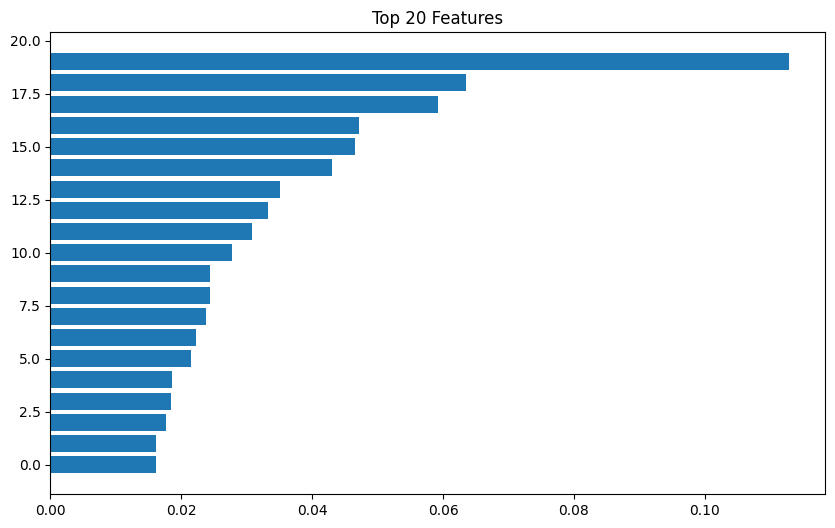

In [18]:
importances = model.feature_importances_

top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(10,6))

plt.barh(range(len(top_idx)), importances[top_idx])

plt.title("Top 20 Features")

plt.show()